In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

print("Librarii incarcate cu succes!")

Librarii incarcate cu succes!


In [3]:
# Definesc numele fisierului CSV care contine datele despre creatorii de continut de pe YouTube
file_name = 'global_youtube_creator_data_large.csv'

# Citim doar 50.000 de randuri pentru a lucra rapid
try:
    df = pd.read_csv(file_name, nrows=5000)
    print(f"Succes! Am incarcat {df.shape[0]} randuri.")
except FileNotFoundError:
    print(f"Eroare: Nu am gasit fisierul {file_name}")

df.head()

Succes! Am incarcat 5000 randuri.


,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled
0,2024-09-14 05:08:02,VID_589765,Vlogs,Japanese,PK,873,6826,396,34,31,-0.082,True
1,2025-08-09 12:23:26,VID_577279,Tech Reviews,Urdu,UK,2335,11371,402,26,19,-0.873,False
2,2024-03-04 14:39:48,VID_890301,Gaming,English,BR,1895,7509,730,45,25,-0.764,True
3,2025-05-04 11:05:26,VID_613444,Education,Urdu,PK,841,17361,1302,122,25,-0.788,True
4,2024-09-22 20:22:31,VID_602671,Gaming,Japanese,IN,1246,18494,756,63,42,0.521,False


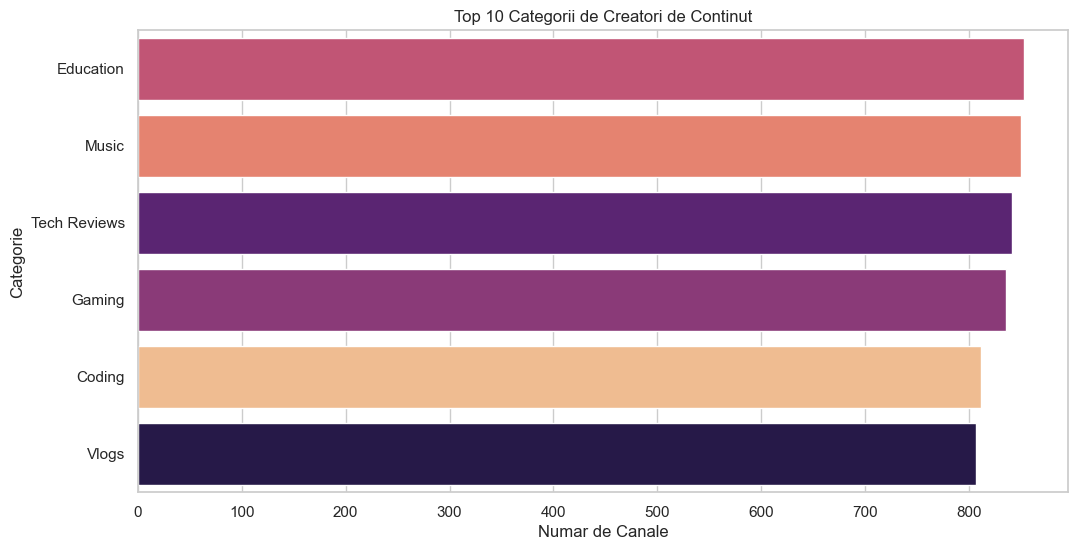

In [4]:
# 1. Setam dimensiunea ferestrei pentru grafic
plt.figure(figsize=(12, 6))

# 2. Cream graficul 
sns.countplot(
    data=df, 
    y='category', 
    order=df['category'].value_counts().index[:10], 
    hue='category', 
    palette='magma',
    legend=False
)

# 3. Adaugam elementele de text
plt.title('Top 10 Categorii de Creatori de Continut')
plt.xlabel('Numar de Canale')
plt.ylabel('Categorie')

plt.show()

In [5]:
#  DATA CLEANING 

# 1. Verificam daca avem valori null in dataset
print("Valori lipsa per coloana:")
print(df.isnull().sum())

# 2. Eliminam coloanele care nu ne ajuta la clasificare (ID-uri, link-uri, imagini)
# Adaptam lista de coloane in functie de ce are dataset-ul 
cols_to_drop = ['channel_id', 'channel_link', 'channel_motto', 'channel_motto_translated']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 3. Stergem randurile care au valori nule in coloanele importante (ex: category)
df_clean = df_clean.dropna(subset=['category'])

# 4. Verificam daca s-au sters duplicatele
df_clean = df_clean.drop_duplicates()

print(f"\nCuratare finalizata!")
print(f"Randuri ramase: {df_clean.shape[0]}")
print(f"Coloane ramase: {df_clean.shape[1]}")

df_clean.head()

Valori lipsa per coloana:
timestamp          0
video_id           0
category           0
language           0
region             0
duration_sec       0
views              0
likes              0
comments           0
shares             0
sentiment_score    0
ads_enabled        0
dtype: int64

Curatare finalizata!
Randuri ramase: 5000
Coloane ramase: 12


,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled
0,2024-09-14 05:08:02,VID_589765,Vlogs,Japanese,PK,873,6826,396,34,31,-0.082,True
1,2025-08-09 12:23:26,VID_577279,Tech Reviews,Urdu,UK,2335,11371,402,26,19,-0.873,False
2,2024-03-04 14:39:48,VID_890301,Gaming,English,BR,1895,7509,730,45,25,-0.764,True
3,2025-05-04 11:05:26,VID_613444,Education,Urdu,PK,841,17361,1302,122,25,-0.788,True
4,2024-09-22 20:22:31,VID_602671,Gaming,Japanese,IN,1246,18494,756,63,42,0.521,False
